# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 5</span>


In quantum physics a **wave function**, $\Psi$, is a mathematical description of the state of a quantum system. The wave function is a complex-valued probability amplitude, and the probabilities for the possible results of measurements made on the system can be derived from it.

For now on, let's consider the simple case of a non-relativistic single particle, without spin, in three spatial dimensions. The state of such a particle is completely described by its wave function, $\Psi(\vec{r},t)$, where $\vec{r}$ is position and $t$ is time.

For one spinless particle, if the wave function is interpreted as a probability amplitude, the square modulus of the wave function, $|\Psi(\vec{r},t)|^2$, is interpreted as the probability density that the particle is at $\vec{r}$ at time $t$. Once we have a probability density, we can use Monte Carlo ...

#### Hydrogen atom
The wave functions of the eigenstates of an electron in a Hydrogen atom (this is the only atom for which the Schroedinger equation has been solved exactly) are expressed in terms of spherical harmonics and generalized Laguerre polynomials. It is convenient to use spherical coordinates, and the wave function can be separated into functions of each coordinate:

$$
\Psi_{n,l,m}(r,\theta,\phi)=
\sqrt{\left(\frac{2}{na_0}\right)^3 \frac{(n-l-1)!}{2n[(n+l)!]}}
e^{-r/na_0}\left(\frac{2r}{na_0}\right)^l L_{n-l-1}^{2l+1}\left(\frac{2r}{na_0}\right)
Y_l^m(\theta,\phi)
$$

where $a_0=4\pi\epsilon_0\hbar^2/m_e e^2=0.0529$ nm is the Bohr radius, $L_{n-l-1}^{2l+1}$ are the generalized Laguerre polynomials of degree $n-l-1$, $n=1,2,...$ is the principal quantum number, $l=0,1, ..., n-1$ the azimuthal quantum number, $m=-l, -l+1, ..., l-1, l$ the magnetic quantum number.

For example, the ground state wave function is:
$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0} 
$$
whereas one of the three $2p$ excited state is:
$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}} r e^{-r/2a_0} \cos(\theta)
$$
<span style="color:blue">Expectation values for the radius turns out to be exactly:
$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0
\quad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5 a_0
$$
</span>


### Exercise 05.1


Use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ **in Cartesian coordinates** using an uniform transition probability $T(\vec{x}|\vec{y})$. Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.

<span style="color:red">Show a picture of your estimations of $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$</span> and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^6$) as a function of the number of blocks, $N$</font>.

- Use Bohr radius units, $a_0$ for distances
- Choose the step of the uniform transition probability $T(\vec{x}|\vec{y})$ in order to obtain 50% of acceptance in both cases
- Choose a reasonable starting point in the 3D space and equilibrate your sampling before to start measuring the radius. What do you observe when you start very far from the origin?
- How large should be the number of Monte Carlo Metropolis steps in each block?
- If you use a multivariate normal transition probability $T(\vec{x}|\vec{y})$, i.e. a Gaussian for each coordinate, your result for $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ is equivalent?

You can use a Python code similar to the following one to observe how the sampled points distribute into the 3D space:

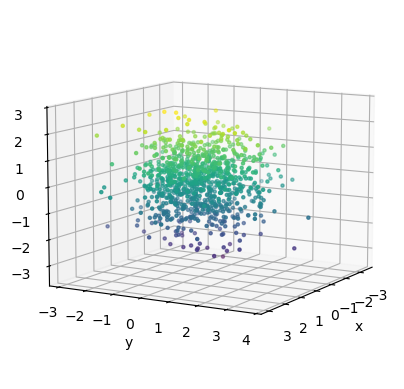

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate random data
M = 1000
X = np.random.normal(0.0, 1.0, M)
Y = np.random.normal(0.0, 1.0, M)
Z = np.random.normal(0.0, 1.0, M)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(X, Y, Z, c=Z, marker='.')

# Axis labels and view
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)

# Show plot
plt.show()

# The Metropolis Algorithm #
----------

The Metropolis algorithm is a Monte Carlo sampling method used for obtaining a sequence of random samples from a probability distribution for which direct sampling (such as accept-reject) is difficult or unpractical. Below is the pseudo-code representation of the Metropolis algorithm:

1. Start at some initial point $x_0$.
2. Propose a new point $x'$ by sampling from a symmetric proposal distribution $q(x'|x)$. Commonly, this is a Gaussian centered at the current point.
3. Compute the acceptance ratio:
   $$ r= \frac{f(x')}{f(x)} $$
4. Accept or reject:
   - With probability $min(1, r)$ accept the move $x_{t+1} = x'$
   - Otherwise reject it and stay at the current point $x_{t+1} = x_t $ <br><br>
5. Repeat steps 2-4 for as many samples as needed
6. **Output** the sequence $\{x_0, x_1, x_2, \dots \}$ as samples from the target distribution.

### <u>Note</u>: ###

In practical cases we already know $f(x)$. The p.d.f. $f(x)$ is the unnormalized target distribution, proportional to the probability density we want to sample from. Consider, for example, the Boltzmann probability distribution function:

$$ P(x) = \frac{ e^{-\frac{E(x)}{k_B T}} }{Z} $$
<br><br>
In practical cases, however, it is often difficult to determine the partition function $Z$ (which acts as a normalizaiton constant). The genius of the Metropolis algorithm is that we don't explicitly need to know the partition function, since it cancels out in the acceptance ratio:<br><br>

$$
r = \frac{f(x')}{f(x)} = \left( \exp\left(-\frac{E(x')}{k_B T}\right) / Z \right) \cdot \left( Z / \exp\left(-\frac{E(x)}{k_B T}\right) \right)
$$

### <u>Note II</u>: ###

The Metropolis algorithm is a power tool that allows to sample virtually any probability distribution. This advantage comes a few drawbacks that are important to take into consideration.

- First of all, the sampled pdf is equal to the target pdf only asymptotically. This means that to get a good approximation, we will need to take an important number of steps.
- Secondly, since each proposed step is dependent on the previous one, the samples are strongly correlated with one another. It is therefore crucial to keep the error in check with the blocking method. 

## Numerical Example: ##

To see the Metropolis Algorithm in action, consider the following p.d.f.

$$ f(x) =
0.3 \cdot \exp\left( -\frac{1}{2} \left( \frac{x - 2}{0.5} \right)^2 \right)
+ 0.7 \cdot \exp\left( -\frac{1}{2} \left( \frac{x + 2}{1.0} \right)^2 \right) $$

The following Python code will run the Metropolis Algorithm for a different number of steps. We will see how well do the various samplings approximate the p.d.f. $f(x)$.

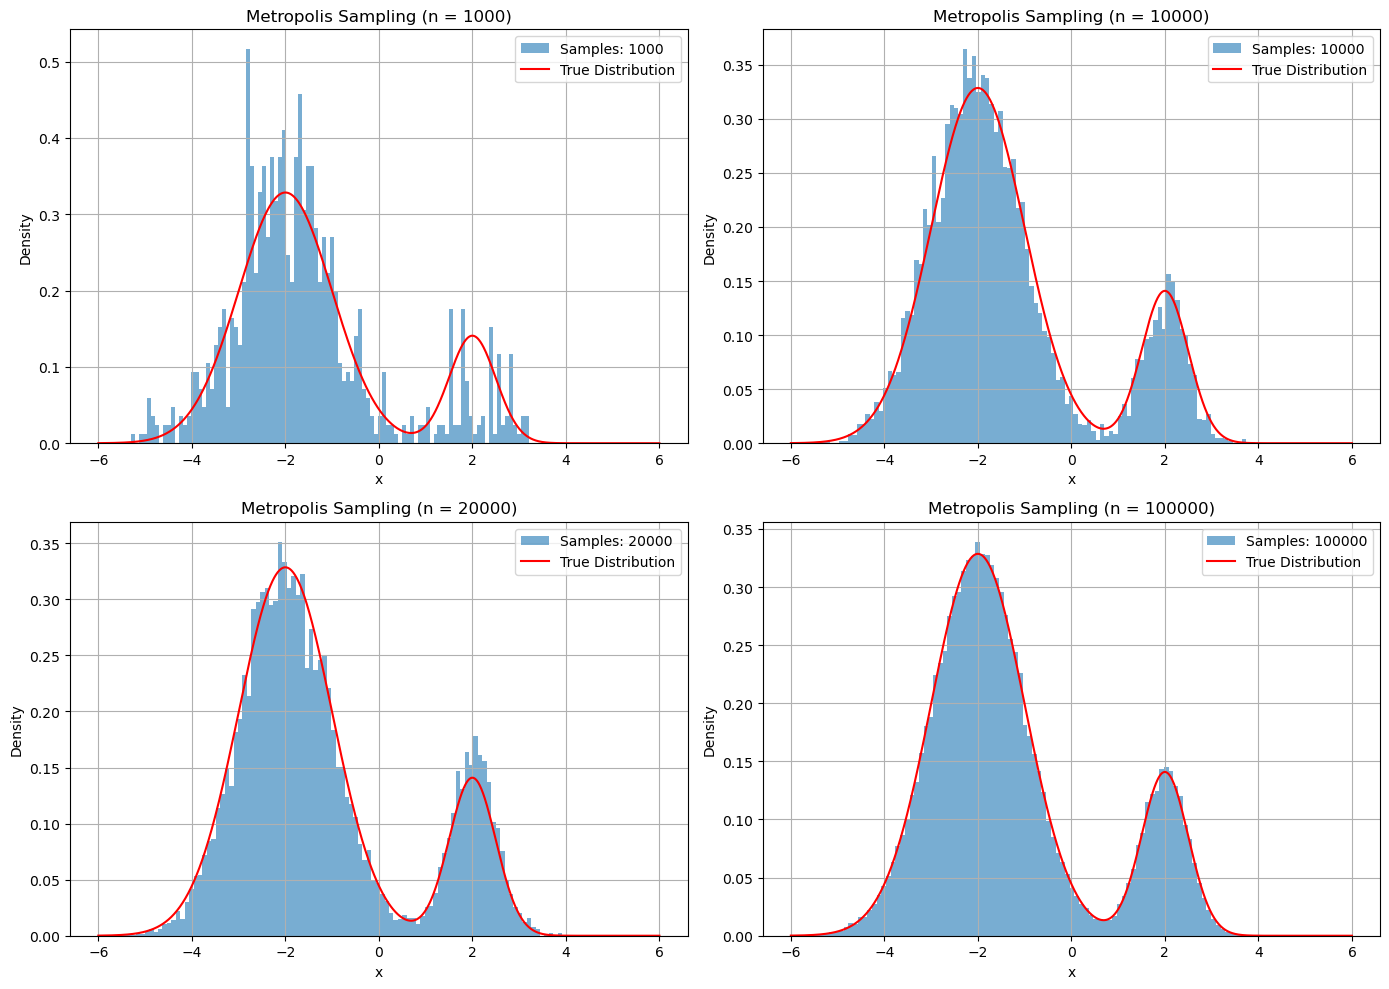

In [2]:
# Target distribution (unnormalized)
def target_dist(x):
    # Mixture of two Gaussians (no need to normalize)
    return (
        0.3 * np.exp(-0.5 * ((x - 2) / 0.5) ** 2) +
        0.7 * np.exp(-0.5 * ((x + 2) / 1.0) ** 2)
    )

# Metropolis algorithm
def metropolis_sampler(f, n_samples=10000, proposal_width=1.0, x0=0.0):
    samples = []
    x = x0

    for _ in range(n_samples):
        # Propose a new candidate from a symmetric distribution (e.g. Normal)
        x_new = np.random.normal(loc=x, scale=proposal_width)

        # Acceptance probability (clipped to 1)
        accept_prob = min(1, f(x_new) / f(x))

        # Accept or reject
        if np.random.rand() < accept_prob:
            x = x_new

        samples.append(x)

    return np.array(samples)

# Sample sizes to test
sample_sizes = [1000, 10000, 20000, 100000]

# Prepare true (normalized) target distribution
x_vals = np.linspace(-6, 6, 1000)
y_vals = target_dist(x_vals)
y_vals /= np.trapz(y_vals, x_vals)  # Normalize for comparison

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    samples = metropolis_sampler(target_dist, n_samples=n, proposal_width=1.0)
    
    axes[i].hist(samples, bins=100, density=True, alpha=0.6, label=f'Samples: {n}')
    axes[i].plot(x_vals, y_vals, 'r-', label='True Distribution')
    axes[i].set_title(f'Metropolis Sampling (n = {n})')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Solution to Exercise 5.1
----------

We are going to use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ **in Cartesian coordinates** using an uniform transition probability $T(\vec{x}|\vec{y})$. 

Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.

## Chosing $T(\vec{x}|\vec{y})$ such that $\alpha \approx 50\%$ ##
--------

The acceptance rate $\alpha$ is simply:

$$
\alpha = \frac{\text{number of accepted moves}}{\text{number of proposed moves}}
$$

How do we define $T(\vec{x}|\vec{y})$ such that $\alpha \approx 50\%$ ? The **empirical** method to do this is to **tweak the step size** until our acceptance rate is roughly what we wanted. 

## Average Position of the Ground State $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ ##

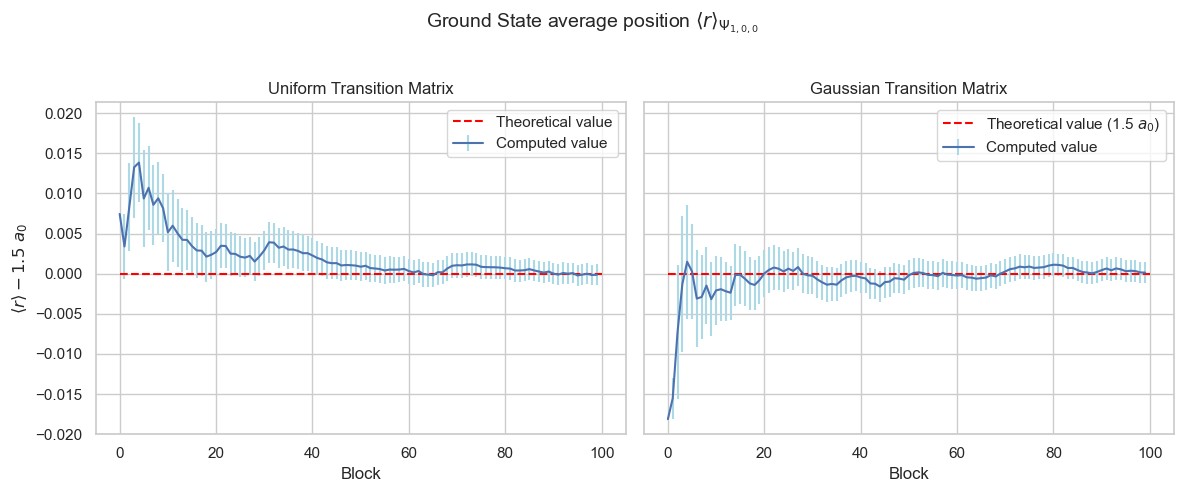

In [3]:
sns.set(style="whitegrid")

uniform_file = "./Data/ground_state_uniform_transition_blocked_stats.dat"
gaussian_file = "./Data/ground_state_gaussian_transition_blocked_stats.dat"

avg_uniform, err_uniform = np.loadtxt(uniform_file, usecols=(0, 1), unpack=True)
avg_gaussian, err_gaussian = np.loadtxt(gaussian_file, usecols=(0, 1), unpack=True)

N = len(avg_uniform)
x = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot Uniform
axes[0].errorbar(x, avg_uniform-1.5, yerr=err_uniform, fmt='-', color='b', ecolor='lightblue', capsize=0, label='Computed value')
axes[0].hlines(0, 0, N, color='red', linestyle='--', label='Theoretical value')
axes[0].set_xlabel("Block")
axes[0].set_ylabel(r'$\langle r \rangle - 1.5\ a_0$')
axes[0].set_title("Uniform Transition Matrix")
axes[0].legend(loc='best')

# Plot Gaussian
axes[1].errorbar(x, avg_gaussian-1.5, yerr=err_gaussian, fmt='-', color='b', ecolor='lightblue', capsize=0, label='Computed value')
axes[1].hlines(0, 0, N, color='red', linestyle='--', label='Theoretical value (1.5 $a_0$)')
axes[1].set_xlabel("Block")
axes[1].set_title("Gaussian Transition Matrix")
axes[1].legend(loc='best')

# Global figure settings
fig.suptitle(r"Ground State average position $\left\langle r \right\rangle_{\Psi_{1,0,0}}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## Average Position of the First Excited State $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ ##

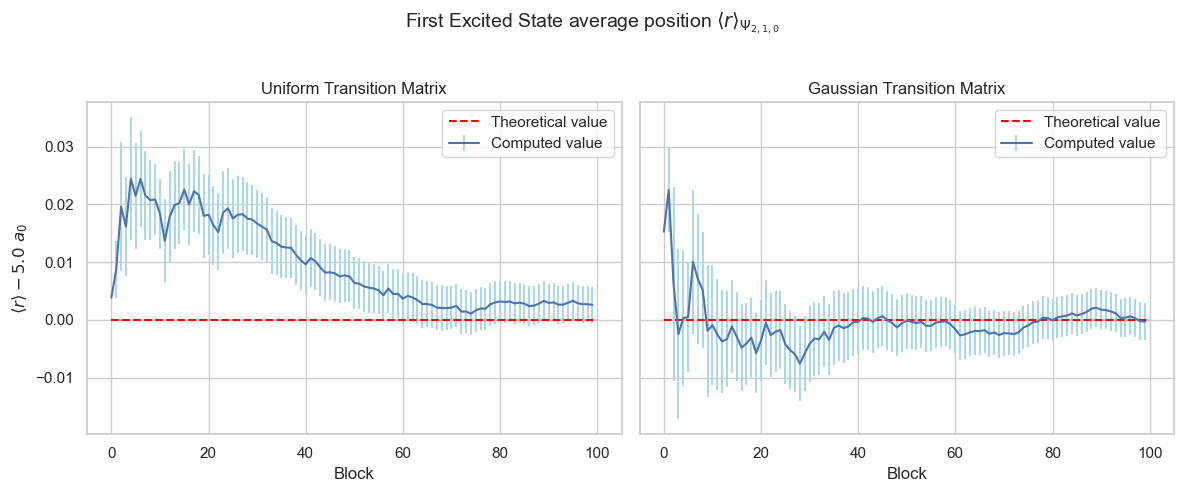

In [4]:
sns.set(style="whitegrid")

uniform_file = "./Data/excited_state_uniform_transition_blocked_stats.dat"
gaussian_file = "./Data/excited_state_gaussian_transition_blocked_stats.dat"

avg_uniform, err_uniform = np.loadtxt(uniform_file, usecols=(0, 1), unpack=True)
avg_gaussian, err_gaussian = np.loadtxt(gaussian_file, usecols=(0, 1), unpack=True)

N = len(avg_uniform)
x = np.arange(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot Uniform
axes[0].errorbar(x, avg_uniform-5.0, yerr=err_uniform, fmt='-', color='b', ecolor='lightblue', capsize=0, label='Computed value')
axes[0].hlines(0, 0, N, color='red', linestyle='--', label='Theoretical value')
axes[0].set_xlabel("Block")
axes[0].set_ylabel(r'$\langle r \rangle - 5.0\ a_0$')
axes[0].set_title("Uniform Transition Matrix")
axes[0].legend(loc='best')

# Plot Gaussian
axes[1].errorbar(x, avg_gaussian-5.0, yerr=err_gaussian, fmt='-', color='b', ecolor='lightblue', capsize=0, label='Computed value')
axes[1].hlines(0, 0, N, color='red', linestyle='--', label='Theoretical value')
axes[1].set_xlabel("Block")
axes[1].set_title("Gaussian Transition Matrix")
axes[1].legend(loc='best')

# Global figure settings
fig.suptitle(r"First Excited State average position $\left\langle r \right\rangle_{\Psi_{2,1,0}}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## A Visual representation of the sampled points $\langle r \rangle$ ## 

**Note:** the datasets to visually represent the sampled points are too heavy to commit via git. To reproduce these results, it is necessary to re-run the program and regenerate the output files.

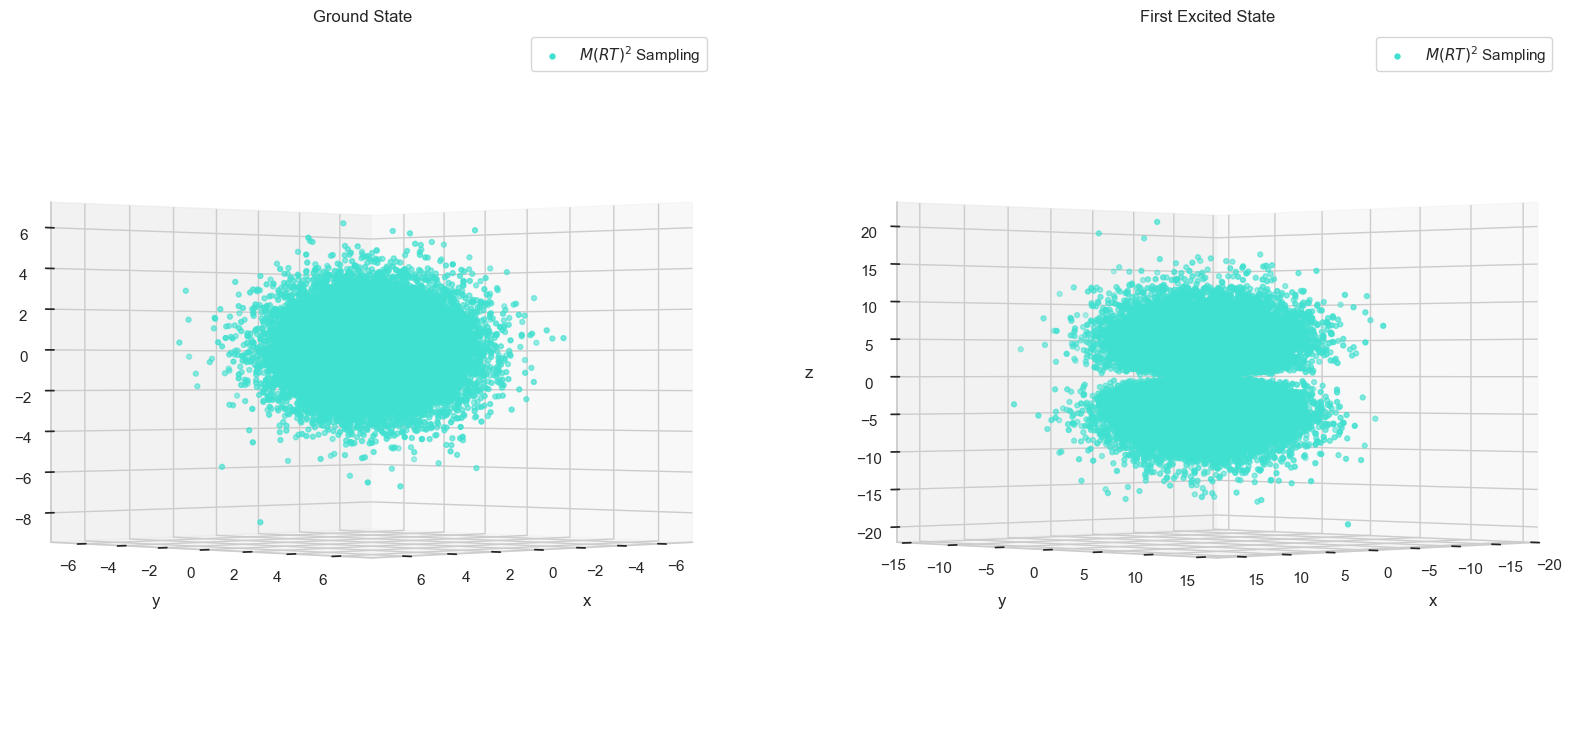

In [5]:
H100 = np.loadtxt("Data/H100.dat")
H210 = np.loadtxt("Data/H210.dat")

# Downsample (show fewer points)
H100 = H100[::100]
H210 = H210[::100]

# Extract coordinates
X1, Y1, Z1 = H100.T
X2, Y2, Z2 = H210.T

# Plot
fig = plt.figure(figsize=(20, 15))

# Ground state
ax = fig.add_subplot(1, 2, 1, projection='3d')
plt.title('Ground State')
ax.scatter(X1, Y1, Z1, color='turquoise', marker='.', s=50, label='$M(RT)^2$ Sampling')
ax.set_xlabel('x', labelpad=15)
ax.set_ylabel('y', labelpad=15)
ax.set_zlabel('z', labelpad=15)
ax.view_init(0, 45)
ax.legend()

# First excited state
ax1 = fig.add_subplot(1, 2, 2, projection='3d')
plt.title('First Excited State')
ax1.scatter(X2, Y2, Z2, color='turquoise', marker='.', s=50, label='$M(RT)^2$ Sampling')
ax1.set_xlabel('x', labelpad=15)
ax1.set_ylabel('y', labelpad=15)
ax1.set_zlabel('z', labelpad=15)
ax1.view_init(0, 45)
ax1.legend()

plt.show()

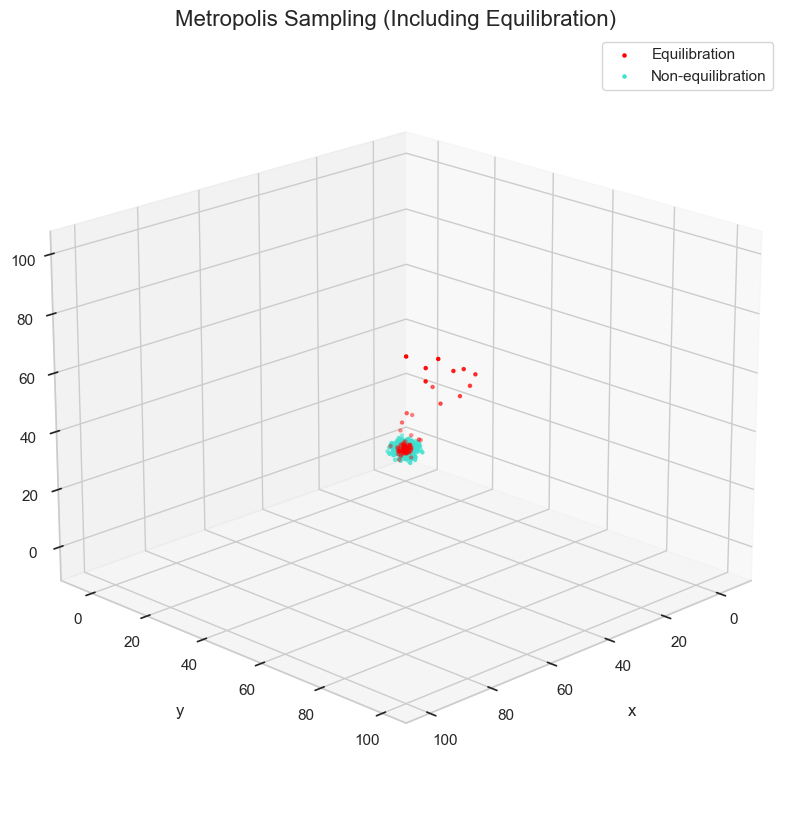

In [11]:
data = np.loadtxt("Data/metropolis_all_far_start.dat")
# Downsample
data = data[::50]

# Separate coordinates
X, Y, Z, R = data.T

Nequi = 100
equilibration = np.arange(len(data)) < Nequi

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Metropolis Sampling (Including Equilibration)", fontsize=16)

# Equilibration points in red
ax.scatter(X[equilibration], Y[equilibration], Z[equilibration], 
           color='red', marker='.', s=20, label='Equilibration')

# Non-equilibration points in turquoise
ax.scatter(X[~equilibration], Y[~equilibration], Z[~equilibration], 
           color='turquoise', marker='.', s=20, label='Non-equilibration')

ax.set_xlabel('x', labelpad=15)
ax.set_ylabel('y', labelpad=15)
ax.set_zlabel('z', labelpad=15)
ax.view_init(20, 45)
ax.legend()
plt.show()
